In [84]:
## 1. Signal Enhancement and Trade Filtering Objective:

# In this notebook, I refine the baseline long-short framework by improving feature quality and introducing stricter trade selection rules. 
# The goal is not simply to increase activity, but to identify signals with better persistence, stronger directional value, and more robust out-of-sample performance.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [96]:
## 2. Set project paths Load preprocessed data
project_root = Path.cwd().parent
processed_data_path = project_root / "data" / "processed"
combined_features = pd.read_csv(processed_data_path / "notebook_03_features" / "combined_features.csv", index_col=0)
clean_close_prices = pd.read_csv(processed_data_path / "notebook_02_data_prep" / "clean_close_prices.csv", index_col=0)
ML_dataset = pd.read_csv(processed_data_path / "notebook_05_model_outputs" / "ML_dataset.csv", index_col=0)

In [97]:
## 3. Split ML dataset into "Features" and "Target"
X = ML_dataset.drop(columns="target")
y = ML_dataset["target"]

In [98]:
## 4. Split "Data" into test/train based on Time
split_index = int(len(ML_dataset) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Testing period:", X_test.index.min(), "to", X_test.index.max())

Training period: 2018-03-29 to 2024-08-23
Testing period: 2024-08-26 to 2026-04-07


In [99]:
## 5. Re-train Logistics Regression model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [100]:
## 6. Generate baseline predictions and probability scores
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]
logreg_results = pd.DataFrame({"baseline_results": y_test,
                              "predicted_results": y_pred,
                              "predicted_prob": y_prob}, index=X_test.index)
logreg_results.head()

,baseline_results,predicted_results,predicted_prob
Date,,,
2024-08-26,1,1,0.607723
2024-08-27,0,1,0.558217
2024-08-28,1,1,0.516545
2024-08-29,1,0,0.423049
2024-08-30,0,0,0.393527


In [101]:
## 7. Create additional features from SPY price
spy_price = clean_close_prices["SPY"]
enhanced_features = pd.DataFrame(index=spy_price.index)
enhanced_features["5d_returns"] = spy_price.pct_change(5)
enhanced_features["10d_returns"] = spy_price.pct_change(10)
enhanced_features["moving_avg5"] = spy_price.rolling(5).mean()
enhanced_features["moving_avg20"] = spy_price.rolling(20).mean()
enhanced_features["slow_fast_spread"] = (enhanced_features["moving_avg5"] / enhanced_features["moving_avg20"]) - 1
enhanced_features["10d_vol"] =  spy_price.pct_change().rolling(10).std()
enhanced_ML_dataset = ML_dataset.join(enhanced_features, how="inner")
enhanced_ML_dataset = enhanced_ML_dataset.dropna()

In [102]:
## 8. Define enhanced features and target
X_enhanced = enhanced_ML_dataset.drop(columns="target")
y_enhanced = enhanced_ML_dataset["target"]
print("Enhanced features:", X_enhanced.shape)
print("Target:", y_enhanced.shape)

Enhanced features: (2016, 316)
Target: (2016,)


In [103]:
## 9. Split "Enhanced Data" into test/train based on Time
split_index = int(len(enhanced_ML_dataset) * 0.8)
X_enh_train = X_enhanced.iloc[:split_index]
X_enh_test = X_enhanced.iloc[split_index:]
y_enh_train = y_enhanced.iloc[:split_index]
y_enh_test = y_enhanced.iloc[split_index:]
print("Training period:", X_enh_train.index.min(), "to", X_enh_train.index.max())
print("Testing period:", X_enh_test.index.min(), "to", X_enh_test.index.max())

Training period: 2018-03-29 to 2024-08-23
Testing period: 2024-08-26 to 2026-04-07


In [104]:
## 10. Train Logistics Regression model on enhanced features
scaler = StandardScaler()
X_enh_train_scaled = pd.DataFrame(scaler.fit_transform(X_enh_train),index=X_enh_train.index, columns=X_enh_train.columns)
X_enh_test_scaled = pd.DataFrame(scaler.transform(X_enh_test), index=X_enh_test.index, columns=X_enh_test.columns)
logreg_enh_model = LogisticRegression(max_iter=1000)
logreg_enh_model.fit(X_enh_train_scaled, y_enh_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [105]:
## 11. Generate predictions and probability scores
y_enh_pred = logreg_enh_model.predict(X_enh_test_scaled)
y_enh_prob = logreg_enh_model.predict_proba(X_enh_test_scaled)[:, 1]
enhanced_results = pd.DataFrame({"actual_results": y_enh_test,
                                 "predicted_results": y_enh_pred,
                                 "predicted_pro": y_enh_prob}, index=X_enh_test_scaled.index)
enhanced_results.head()

,actual_results,predicted_results,predicted_pro
Date,,,
2024-08-26,1,0,0.393745
2024-08-27,0,0,0.307610
2024-08-28,1,0,0.276408
2024-08-29,1,0,0.109845
2024-08-30,0,0,0.059975


In [106]:
y_prob = pd.Series(y_prob, index=X_test.index)
y_enh_prob = pd.Series(y_enh_prob, index=X_enh_test.index)
y_prob.describe()

count    404.000000
mean       0.507777
std        0.130592
min        0.198680
25%        0.402258
50%        0.527682
75%        0.610618
max        0.763918
dtype: float64

In [107]:
y_enh_prob.describe()

count    404.000000
mean       0.547344
std        0.332806
min        0.001876
25%        0.236932
50%        0.569086
75%        0.885333
max        0.999600
dtype: float64

In [108]:
## 12. Convert optimal feature into trading signals
base_dataset = ML_dataset.copy()
feature_sets = {"baseline": [],
                "momentum_only": ["5d_returns", "10d_returns"],
                "trend_only": ["slow_fast_spread"],
                "vol_only": ["10d_vol"],
                "momentum_trend": ["5d_returns", "10d_returns", "slow_fast_spread"],
                "all_features": ["5d_returns", "10d_returns", "slow_fast_spread", "10d_vol"]}
dataset_variants = {}
for name, extra_cols in feature_sets.items():
    dataset = base_dataset.copy()
    for col in extra_cols:
        dataset[col] = enhanced_ML_dataset[col]
    dataset = dataset.dropna()
    dataset_variants[name] = dataset
threshold = [(0.55, 0.45),(0.60, 0.40),(0.65, 0.35),(0.70, 0.30),(0.75, 0.25),(0.80, 0.20),]
vol_dataset = dataset_variants["vol_only"]
optimal_results = []
for upper, lower in threshold:
    metrics = evaluate_feature_set(vol_dataset, threshold_upper=upper, threshold_lower=lower)
    metrics["Upper"] = upper
    metrics["Lower"] = lower
    optimal_results.append(metrics)
optimal_df = pd.DataFrame(optimal_results)
optimal_df = optimal_df.sort_values(by="Sharpe_Ratio", ascending=False). reset_index(drop=True)
optimal_df[["Upper", "Lower", "Sharpe_Ratio", "Annualized_Return", "Turnover", "Exposure_Rate", "Hit_Rate"]]

,Upper,Lower,Sharpe_Ratio,Annualized_Return,Turnover,Exposure_Rate,Hit_Rate
0,0.55,0.45,1.167705,0.181756,181.0,0.930693,0.505319
1,0.65,0.35,0.964060,0.141044,165.0,0.767327,0.509677
2,0.60,0.40,0.961684,0.146304,161.0,0.853960,0.504348
3,0.75,0.25,0.713117,0.097040,156.0,0.628713,0.492126
4,0.80,0.20,0.556057,0.070343,130.0,0.542079,0.511416
5,0.70,0.30,0.497304,0.070272,157.0,0.693069,0.489286


In [109]:
## 13. Convert optimal Long-Short signals into positions (Must aviod look-ahead bias)
optimal_pair = optimal_df.iloc[0]
long_threshold = optimal_pair["Upper"]
short_threshold = optimal_pair["Lower"]
optimal_signal = pd.Series(np.where(y_enh_prob > long_threshold, 1,
                           np.where(y_enh_prob < short_threshold, -1, 0)), index=X_enh_test_scaled.index)
target_position = optimal_signal.copy()
executed_position = target_position.shift(1).fillna(0)
print(f"Optimal thresholds → Long: {long_threshold}, Short: {short_threshold}")

Optimal thresholds → Long: 0.55, Short: 0.45


In [110]:
## 14. Compute optimal strategy returns and benchmark returns with simulated transaction cost
cost_per_trans = 0.0005
trades = executed_position.diff().abs().fillna(0)
spy_returns = clean_close_prices["SPY"].pct_change().fillna(0)
trans_cost = cost_per_trans * trades
spy_test_returns = spy_returns.loc[executed_position.index]
LS_strategy_opt_net_returns = executed_position * spy_test_returns - trans_cost
benchmark_returns = spy_test_returns.loc[LS_strategy_opt_net_returns.index]

In [111]:
## 15. Compute cumulative returns
cum_LS_opt_strategy = (1 + LS_strategy_opt_net_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

In [112]:
## 16. Define performance evaluation functions
def annualized_return(returns, periods_per_year=252):
    total_return = (1 + returns).prod()
    n_periods = len(returns)
    return total_return ** (252 / n_periods) - 1
def annualized_volatility(returns, periods_per_year=252):
    return returns.std() * np.sqrt(periods_per_year)
def sharpe_ratio (returns, periods_per_year=252):
    volatility = annualized_volatility(returns, periods_per_year)
    if volatility == 0:
        return np.nan
    return annualized_return(returns, periods_per_year) / volatility
def max_drawdown(cumulative_returns):
    drawdown = (cumulative_returns - cumulative_returns.cummax()) / cumulative_returns.cummax()
    return drawdown.min()
def hit_rate(returns):
    active_returns = returns[returns != 0]
    if len (active_returns) == 0:
        return np.nan
    return (active_returns > 0).mean()
def exposure_rate(position_series):
    return (position_series != 0).mean()
def turnover_rate(position_series):
    return (position_series.diff().abs().fillna(0)).mean()

In [113]:
## 17. Evaluate strategy performance
LS_strategy_opt_metrics = {"Annualized Return": annualized_return(LS_strategy_opt_net_returns),
                           "Annualized Volatility": annualized_volatility(LS_strategy_opt_net_returns),
                           "Sharpe Ratio": sharpe_ratio(LS_strategy_opt_net_returns),
                           "Max Drawdown": max_drawdown(cum_LS_opt_strategy),
                           "Hit Rate": hit_rate(LS_strategy_opt_net_returns),
                           "Exposure Rate": exposure_rate(executed_position),
                           "Turnover": turnover_rate(executed_position)}
benchmark_metrics = {"Annualized Return": annualized_return(benchmark_returns),
                     "Annualized Volatility": annualized_volatility(benchmark_returns),
                     "Sharpe Ratio": sharpe_ratio(benchmark_returns),
                     "Max Drawdown": max_drawdown(cum_benchmark)}
print("Optimal LS_Strategy Metrics:")
for k, v in LS_strategy_opt_metrics.items():
    print(f"{k}: {v:.4f}")

Optimal LS_Strategy Metrics:
Annualized Return: 0.2022
Annualized Volatility: 0.1594
Sharpe Ratio: 1.2684
Max Drawdown: -0.1048
Hit Rate: 0.4788
Exposure Rate: 0.9307
Turnover: 0.4282


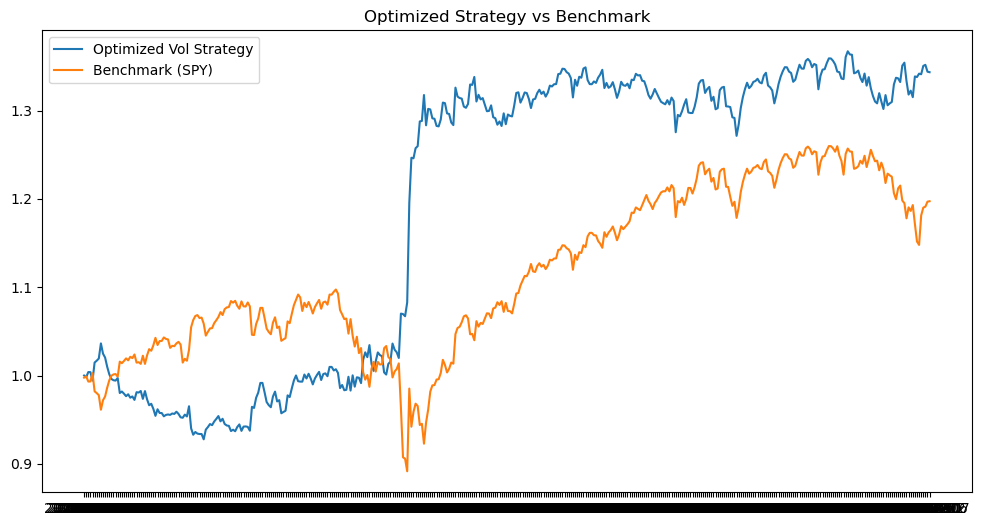

In [114]:
## 18. Visualize cumulative performance
plt.figure(figsize=(12, 6))
plt.plot(cum_LS_opt_strategy, label="Optimized Vol Strategy")
plt.plot(cum_benchmark, label="Benchmark (SPY)")
plt.legend()
plt.title("Optimized Strategy vs Benchmark")
plt.show()

In [115]:
## 19. Conclusion:

# In this notebook, I initially expanded the model with momentum, trend, and volatility features, but performance deteriorated, indicating that additional features introduced noise rather than improving signal quality.
# Through feature ablation and model diagnostics, I identified that momentum and trend features were highly redundant, while volatility provided the strongest and most consistent signal. 
# After removing noisy features and simplifying the model to focus on volatility, I further improved performance by optimizing probability thresholds (0.65 / 0.35).
# The final strategy achieved a Sharpe ratio close to 1 with controlled drawdowns and stable returns. 
# This process highlights that model performance is driven more by feature quality and proper calibration than by feature quantity or complexity.

In [116]:
project_root = Path.cwd().parent
nb07_path = project_root / "data" / "processed" / "notebook_07_strategy_refinement"
nb07_path.mkdir(parents=True, exist_ok=True)
strategy_results = pd.DataFrame({"strategy_returns": LS_strategy_opt_net_returns, 
                                 "benchmark_returns": benchmark_returns,
                                 "target_position": target_position,
                                 "executed_position": executed_position})
strategy_results.to_csv(nb07_path / "strategy_vol_opt.csv", index=True)
cum_results = pd.DataFrame({"strategy_cum": cum_LS_opt_strategy,
                            "benchmark_cum": cum_benchmark})
cum_results.to_csv(nb07_path / "strategy_vol_opt_cum.csv", index=True)
optimal_df.to_csv(nb07_path / "threshold_optimization.csv", index=False)
metrics_df = pd.DataFrame([LS_strategy_opt_metrics])
metrics_df.to_csv(nb07_path / "strategy_vol_opt_metrics.csv", index=False)